# Financial Market Data Analysis with Python

## Project Overview

This project analyzes historical stock market data from major technology companies.

The objective is to collect, clean, analyze and visualize financial market data in order to compare company performance, identify trends and generate business insights.

### Companies analyzed

- Apple (AAPL)
- Microsoft (MSFT)
- Amazon (AMZN)
- Google (GOOGL)
- Tesla (TSLA)

### Business Questions

1. Which company achieved the highest historical performance?
2. How did stock prices evolve over time?
3. Which company was the most volatile?
4. How do the companies compare in terms of performance?
5. What major trends can be identified?
6. What insights and recommendations can be derived from the analysis?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pip install yfinance

In [3]:
import yfinance as yf

In [4]:
tickers =["AAPL", "MSFT", "AMZN", "GOOGL", "TSLA"]


In [5]:
data =yf.download(tickers, start= "2020-01-01", end="2025-12-31", auto_adjust =False)

[*********************100%***********************]  5 of 5 completed


In [6]:
data.head()

Price       Adj Close                                                   Close  \
Ticker           AAPL       AMZN      GOOGL        MSFT       TSLA       AAPL   
Date                                                                            
2020-01-02  72.271561  94.900497  67.788933  151.544250  28.684000  75.087502   
2020-01-03  71.568909  93.748497  67.434326  149.657288  29.534000  74.357498   
2020-01-06  72.139198  95.143997  69.231720  150.044098  30.102667  74.949997   
2020-01-07  71.799934  95.343002  69.097984  148.675995  31.270666  74.597504   
2020-01-08  72.954926  94.598503  69.589813  151.044189  32.809334  75.797501   

Price                                                    ...       Open  \
Ticker           AMZN      GOOGL        MSFT       TSLA  ...       AAPL   
Date                                                     ...              
2020-01-02  94.900497  68.433998  160.619995  28.684000  ...  74.059998   
2020-01-03  93.748497  68.075996  158.619995  29.534000  ...  74.287498   
2020-01-06  95.143997  69.890503  159.029999  30.102667  ...  73.447502   
2020-01-07  95.343002  69.755501  157.580002  31.270666  ...  74.959999   
2020-01-08  94.598503  70.251999  160.089996  32.809334  ...  74.290001   

Price                                                       Volume            \
Ticker           AMZN      GOOGL        MSFT       TSLA       AAPL      AMZN   
Date                                                                           
2020-01-02  93.750000  67.420502  158.779999  28.299999  135480400  80580000   
2020-01-03  93.224998  67.400002  158.320007  29.366667  146322800  75288000   
2020-01-06  93.000000  67.581497  157.080002  29.364668  118387200  81236000   
2020-01-07  95.224998  70.023003  159.320007  30.760000  108872000  80898000   
2020-01-08  94.902000  69.740997  158.929993  31.580000  132079200  70160000   

Price                                      
Ticker         GOOGL      MSFT       TSLA  
Date                                       
2020-01-02  27278000  22622100  142981500  
2020-01-03  23408000  21116200  266677500  
2020-01-06  46768000  20813700  151995000  
2020-01-07  34330000  21634100  268231500  
2020-01-08  35314000  27746500  467164500  

[5 rows x 30 columns]

In [7]:
close_prices = data["Close"]
close_prices.head()

Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2020-01-02,75.087502,94.900497,68.433998,160.619995,28.684000
2020-01-03,74.357498,93.748497,68.075996,158.619995,29.534000
2020-01-06,74.949997,95.143997,69.890503,159.029999,30.102667
2020-01-07,74.597504,95.343002,69.755501,157.580002,31.270666
2020-01-08,75.797501,94.598503,70.251999,160.089996,32.809334


In [8]:
close_prices.shape

(1507, 5)

In [9]:
close_prices.isnull().sum()

,0
Ticker,
AAPL,0
AMZN,0
GOOGL,0
MSFT,0
TSLA,0


In [10]:
close_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1507 entries, 2020-01-02 to 2025-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1507 non-null   float64
 1   AMZN    1507 non-null   float64
 2   GOOGL   1507 non-null   float64
 3   MSFT    1507 non-null   float64
 4   TSLA    1507 non-null   float64
dtypes: float64(5)
memory usage: 70.6 KB


In [11]:
close_prices.describe()

Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
count,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000
mean,166.992130,158.429565,134.178340,322.429423,237.086310
std,48.916762,39.963422,49.603062,98.870448,97.195563
min,56.092499,81.820000,52.706501,135.419998,24.081333
25%,134.614998,127.125000,99.970001,243.014999,182.964996
50%,166.020004,160.061005,130.250000,304.209991,235.860001
75%,198.129997,183.130005,160.985001,411.070007,291.590012
max,286.190002,254.000000,323.440002,542.070007,489.880005


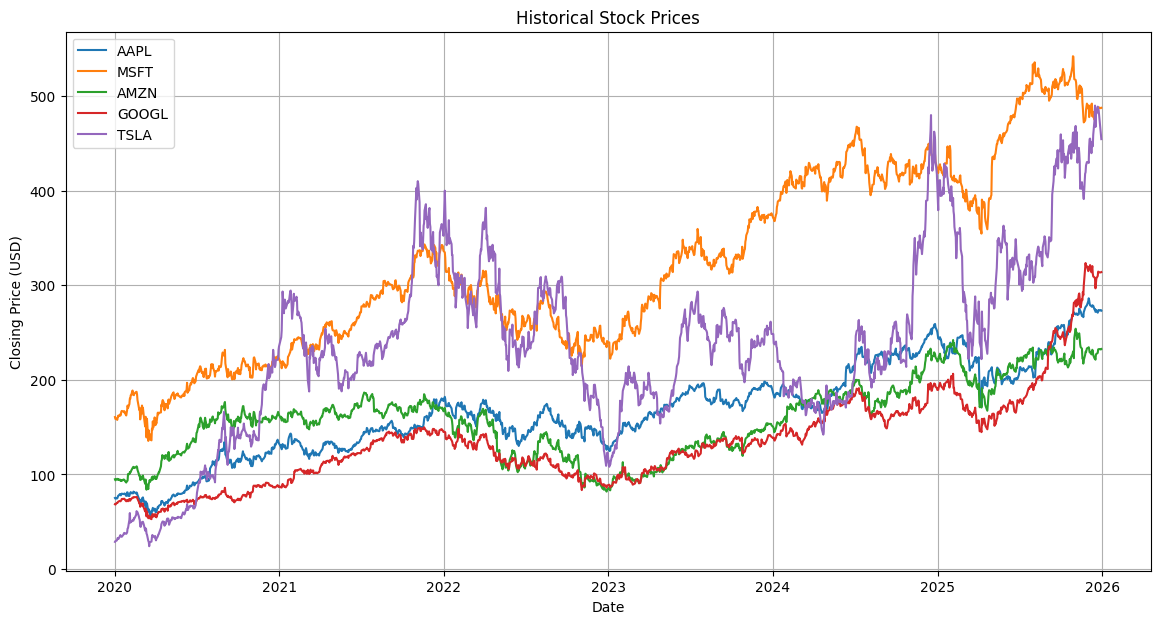

In [12]:
plt.figure(figsize=(14, 7))

for ticker in tickers:
    plt.plot(close_prices[ticker], label=ticker)

plt.title("Historical Stock Prices")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
start_prices = close_prices.iloc[0]

In [14]:
end_prices = close_prices.iloc[-1]

In [15]:
performance = ((end_prices - start_prices)/start_prices)*100

In [16]:
performance_df = pd.DataFrame({"Ticker":performance.index, "Total Return (%)": performance.values})
performance_df = performance_df.sort_values (
    by="Total Return (%)",
    ascending =False
)
performance_df

,Ticker,Total Return (%)
4,TSLA,1484.262977
2,GOOGL,358.617083
0,AAPL,263.682345
3,MSFT,203.498958
1,AMZN,145.025058


In [17]:
normalized_prices=(close_prices/close_prices.iloc[0])*100

In [18]:
normalized_prices.head()

Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2020-01-02,100.000000,100.000000,100.000000,100.000000,100.000000
2020-01-03,99.027796,98.786097,99.476866,98.754825,102.963326
2020-01-06,99.816874,100.256584,102.128335,99.010088,104.945847
2020-01-07,99.347431,100.466283,101.931062,98.107338,109.017801
2020-01-08,100.945562,99.681778,102.656575,99.670029,114.382003


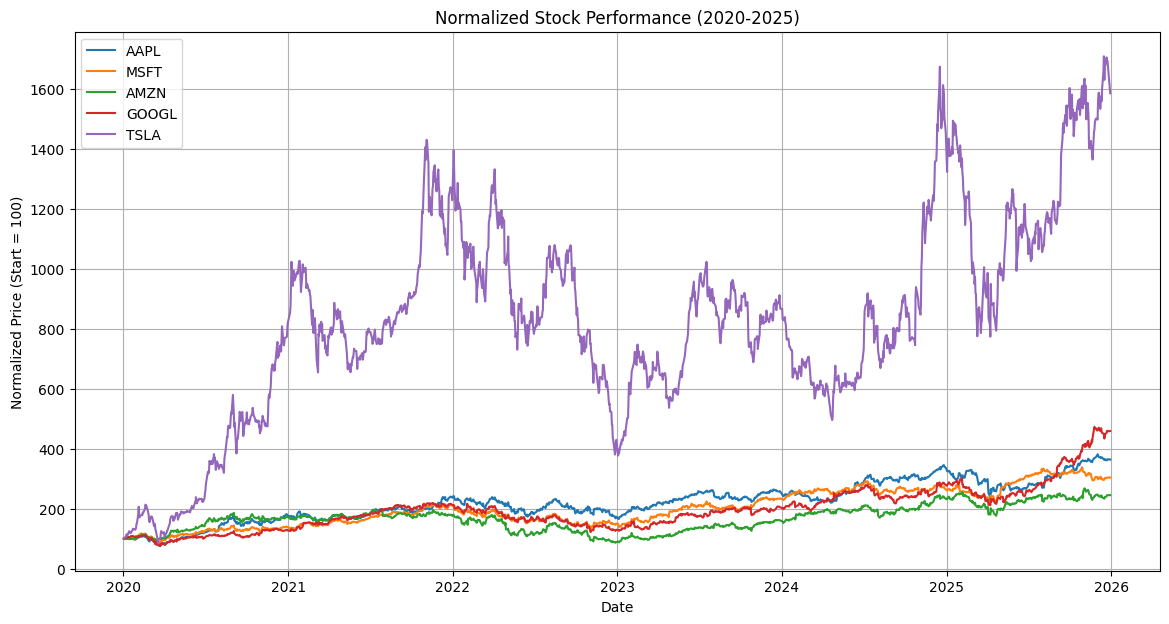

In [19]:
plt.figure(figsize=(14,7))
for ticker in tickers:
  plt.plot(normalized_prices[ticker], label=ticker)

plt.title("Normalized Stock Performance (2020-2025)")
plt.xlabel("Date")
plt.ylabel("Normalized Price (Start = 100)")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
daily_returns = close_prices.pct_change()
daily_returns.head()

Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.009722,-0.012139,-0.005231,-0.012452,0.029633
2020-01-06,0.007968,0.014886,0.026654,0.002585,0.019255
2020-01-07,-0.004703,0.002092,-0.001932,-0.009118,0.038801
2020-01-08,0.016086,-0.007809,0.007118,0.015928,0.049205


Measuring volatility



In [21]:
volatility = daily_returns.std()
volatility

,0
Ticker,
AAPL,0.020043
AMZN,0.022497
GOOGL,0.020463
MSFT,0.018624
TSLA,0.041948


In [22]:
#Volatility_Percentage
volatility_pct = volatility*100
volatility_pct

,0
Ticker,
AAPL,2.004280
AMZN,2.249703
GOOGL,2.046349
MSFT,1.862358
TSLA,4.194831


In [23]:
kpi_df = pd.DataFrame({
    "Ticker":performance.index,
    "Total Return (%)": performance.values,
    "Daily Volatility (%)": volatility_pct.values
})
kpi_df

,Ticker,Total Return (%),Daily Volatility (%)
0,AAPL,263.682345,2.004280
1,AMZN,145.025058,2.249703
2,GOOGL,358.617083,2.046349
3,MSFT,203.498958,1.862358
4,TSLA,1484.262977,4.194831


In [24]:
kpi_df = kpi_df.sort_values(
    by="Total Return (%)",
    ascending =False
).reset_index(drop =True)
kpi_df

,Ticker,Total Return (%),Daily Volatility (%)
0,TSLA,1484.262977,4.194831
1,GOOGL,358.617083,2.046349
2,AAPL,263.682345,2.004280
3,MSFT,203.498958,1.862358
4,AMZN,145.025058,2.249703


In [25]:
kpi_df["Return/Volatility"]= (
    kpi_df["Total Return (%)"] /
    kpi_df["Daily Volatility (%)"]
)
kpi_df

,Ticker,Total Return (%),Daily Volatility (%),Return/Volatility
0,TSLA,1484.262977,4.194831,353.831428
1,GOOGL,358.617083,2.046349,175.247231
2,AAPL,263.682345,2.004280,131.559653
3,MSFT,203.498958,1.862358,109.269499
4,AMZN,145.025058,2.249703,64.464080


In [39]:
#Number of trading days in a year
trading_days = 252

#Average daily returns
mean_daily_return = daily_returns.mean()

#Daily volatility
daily_volatility = daily_returns.std()

#Annualized return (arithmetic approximation)
#annualized_return = mean_daily_return * trading_days

#Annualized volatility
#annualized_volatility = annualized_return * np.sqrt(trading_days)

#Annualized Sharpe Ration, assuming a 0% risk-free rate
sharpe_ratio_annualized = (
    mean_daily_return / daily_volatility
) * np.sqrt(252)

sharpe_ratio_annualized


,0
Ticker,
AAPL,0.837803
AMZN,0.598250
GOOGL,0.947242
MSFT,0.776250
TSLA,1.026126


In [41]:
sharpe_df = pd.DataFrame({
    "Ticker": sharpe_ratio_annualized.index,
    "Annualized Sharpe Ratio": sharpe_ratio_annualized.values
})

sharpe_df = sharpe_df.sort_values(
    by="Annualized Sharpe Ratio",
    ascending=False
).reset_index(drop=True)

sharpe_df.round(3)

,Ticker,Annualized Sharpe Ratio
0,TSLA,1.026
1,GOOGL,0.947
2,AAPL,0.838
3,MSFT,0.776
4,AMZN,0.598


In [33]:
#Verify the calculation using daily returns.
print("Mean daily return:")
print(mean_daily_return)

print("\nDaily volatility:")
print(daily_volatility)

print("\nSharpe Ratio:")
print(sharpe_ratio)

Mean daily return:
Ticker
AAPL     0.001058
AMZN     0.000848
GOOGL    0.001221
MSFT     0.000911
TSLA     0.002712
dtype: float64

Daily volatility:
Ticker
AAPL     0.020043
AMZN     0.022497
GOOGL    0.020463
MSFT     0.018624
TSLA     0.041948
dtype: float64

Sharpe Ratio:
Ticker
AAPL     0.062994
AMZN     0.062994
GOOGL    0.062994
MSFT     0.062994
TSLA     0.062994
dtype: float64


In [34]:
check_sharpe = mean_daily_return / daily_volatility

print(check_sharpe)

Ticker
AAPL     0.052777
AMZN     0.037686
GOOGL    0.059671
MSFT     0.048899
TSLA     0.064640
dtype: float64


In [38]:
check_sharpe * np.sqrt(252)


,0
Ticker,
AAPL,0.837803
AMZN,0.598250
GOOGL,0.947242
MSFT,0.776250
TSLA,1.026126


In [44]:
#Calculate the running Maximum Drawdown for each stock
rolling_max = close_prices.cummax()

#Calculate drawdown as a percentage
drawdown = (close_prices/rolling_max)-1

#Find the maximum drawdown for each stock
max_drawdown = drawdown.min() * 100

max_drawdown.sort_values()


,0
Ticker,
TSLA,-73.632217
AMZN,-56.145263
GOOGL,-44.320051
MSFT,-37.556466
AAPL,-33.433710


Calculate Average Trading Volume


In [46]:
#extract volume data from data frame "data"
volume_data= data["Volume"]
volume_data.head()

Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2020-01-02,135480400,80580000,27278000,22622100,142981500
2020-01-03,146322800,75288000,23408000,21116200,266677500
2020-01-06,118387200,81236000,46768000,20813700,151995000
2020-01-07,108872000,80898000,34330000,21634100,268231500
2020-01-08,132079200,70160000,35314000,27746500,467164500


In [48]:
average_trading_volume = volume_data.mean()
average_trading_volume = average_trading_volume/1_000_000
average_trading_volume.sort_values(ascending=False).round(2)

,0
Ticker,
TSLA,120.97
AAPL,84.58
AMZN,64.53
GOOGL,33.63
MSFT,27.58


Construct the final KPI table


In [55]:
final_kpi=pd.DataFrame({
    "Total Return (%)" : performance,
    "Daily Volatility(%)": daily_returns.std() * 100,
    "Sharpe Ratio": sharpe_ratio_annualized,
    "Maximum Drawdown (%)": max_drawdown})
final_kpi.index.name = "Ticker"
final_kpi = final_kpi.sort_values(by="Sharpe Ratio", ascending=False)
final_kpi.round(2)

,Total Return (%),Daily Volatility(%),Sharpe Ratio,Maximum Drawdown (%)
Ticker,,,,
TSLA,1484.26,4.19,1.03,-73.63
GOOGL,358.62,2.05,0.95,-44.32
AAPL,263.68,2.00,0.84,-33.43
MSFT,203.50,1.86,0.78,-37.56
AMZN,145.03,2.25,0.60,-56.15


In [59]:
volume_data = data["Volume"]

print(volume_data.head())
print(volume_data.dtypes)

average_trading_volume = volume_data.mean()
average_volume_millions = average_trading_volume / 1_000_000

print(average_volume_millions)

Ticker           AAPL      AMZN     GOOGL      MSFT       TSLA
Date                                                          
2020-01-02  135480400  80580000  27278000  22622100  142981500
2020-01-03  146322800  75288000  23408000  21116200  266677500
2020-01-06  118387200  81236000  46768000  20813700  151995000
2020-01-07  108872000  80898000  34330000  21634100  268231500
2020-01-08  132079200  70160000  35314000  27746500  467164500
Ticker
AAPL     int64
AMZN     int64
GOOGL    int64
MSFT     int64
TSLA     int64
dtype: object
Ticker
AAPL      84.575324
AMZN      64.528216
GOOGL     33.625452
MSFT      27.577351
TSLA     120.969042
dtype: float64


In [60]:
final_kpi["Average Trading Volume (M)"] = average_volume_millions

final_kpi.round(2)

,Total Return (%),Daily Volatility(%),Sharpe Ratio,Maximum Drawdown (%),Average Trading Volume (M)
Ticker,,,,,
TSLA,1484.26,4.19,1.03,-73.63,120.97
GOOGL,358.62,2.05,0.95,-44.32,33.63
AAPL,263.68,2.00,0.84,-33.43,84.58
MSFT,203.50,1.86,0.78,-37.56,27.58
AMZN,145.03,2.25,0.60,-56.15,64.53


In [62]:
%pip install plotly

In [63]:
company_colors = {
    "TSLA": "#EF4444",
    "GOOGL": "#1683F8",
    "AAPL": "#8B8B8B",
    "MSFT": "#F59E0B",
    "AMZN": "#8B3FE8"
}

In [64]:
import plotly.express as px

plot_df = final_kpi.reset_index()

fig = px.bar(
    plot_df,
    x="Ticker",
    y="Total Return (%)",
    color="Ticker",
    color_discrete_map=company_colors,
    text="Total Return (%)",
    title="Total Stock Returns by Company (2020–2025)"
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Company",
    yaxis_title="Total Return (%)",
    template="plotly_white",
    showlegend=False,
    height=500
)

fig.show()

In [65]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

metrics = [
    "Total Return (%)",
    "Daily Volatility(%)",
    "Sharpe Ratio",
    "Maximum Drawdown (%)",
    "Average Trading Volume (M)"
]

fig = make_subplots(
    rows=3,
    cols=2,
    subplot_titles=metrics,
    vertical_spacing=0.15,
    horizontal_spacing=0.12
)

for i, metric in enumerate(metrics):
    row = i // 2 + 1
    col = i % 2 + 1

    fig.add_trace(
        go.Bar(
            x=final_kpi.index,
            y=final_kpi[metric],
            marker_color=[
                company_colors[ticker]
                for ticker in final_kpi.index
            ],
            text=final_kpi[metric].round(2),
            textposition="outside",
            showlegend=False
        ),
        row=row,
        col=col
    )

fig.update_layout(
    title="Financial Performance & Risk Dashboard (2020–2025)",
    template="plotly_white",
    height=1100,
    width=1100
)

fig.show()

In [66]:
# Improve the existing dashboard layout

fig.update_layout(
    title={
        "text": "Financial Market Analysis | Tech Stocks (2020–2025)",
        "x": 0.5,
        "xanchor": "center",
        "font": {"size": 24}
    },
    template="plotly_white",
    height=1200,
    width=1200,
    margin=dict(t=120, b=70, l=70, r=70),
    font=dict(size=13),
    bargap=0.25
)

# Improve bar labels
fig.update_traces(
    texttemplate="%{text:.2f}",
    textposition="outside",
    cliponaxis=False
)

# Add a shared color legend
for ticker, color in company_colors.items():
    fig.add_trace(
        go.Bar(
            x=[None],
            y=[None],
            name=ticker,
            marker_color=color,
            showlegend=True
        ),
        row=3,
        col=2
    )

fig.update_layout(
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.04,
        xanchor="center",
        x=0.5
    )
)

fig.show()

In [67]:
# Hide the empty sixth subplot
fig.update_xaxes(visible=False, row=3, col=2)
fig.update_yaxes(visible=False, row=3, col=2)

# Add a business summary in the empty space
fig.add_annotation(
    x=0.78,
    y=0.12,
    xref="paper",
    yref="paper",
    text=(
        "<b>KEY FINDINGS</b><br><br>"
        "TSLA: Highest total return<br>"
        "TSLA: Highest volatility<br>"
        "AAPL: Lowest maximum drawdown<br>"
        "MSFT: Lowest daily volatility<br>"
        "TSLA: Highest average trading volume"
    ),
    showarrow=False,
    align="left",
    font=dict(size=15)
)

fig.show()

In [68]:
print("First date:", data.index.min())
print("Last date:", data.index.max())

print("\nClose prices:")
display(data["Close"].head())

print("\nAdjusted close prices:")
display(data["Adj Close"].head())

print("\nDifference between Close and Adj Close:")
display(
    (data["Close"] - data["Adj Close"])
    .abs()
    .max()
)

First date: 2020-01-02 00:00:00
Last date: 2025-12-30 00:00:00

Close prices:


Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2020-01-02,75.087502,94.900497,68.433998,160.619995,28.684000
2020-01-03,74.357498,93.748497,68.075996,158.619995,29.534000
2020-01-06,74.949997,95.143997,69.890503,159.029999,30.102667
2020-01-07,74.597504,95.343002,69.755501,157.580002,31.270666
2020-01-08,75.797501,94.598503,70.251999,160.089996,32.809334



Adjusted close prices:


Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2020-01-02,72.271561,94.900497,67.788933,151.544250,28.684000
2020-01-03,71.568909,93.748497,67.434326,149.657288,29.534000
2020-01-06,72.139198,95.143997,69.231720,150.044098,30.102667
2020-01-07,71.799934,95.343002,69.097984,148.675995,31.270666
2020-01-08,72.954926,94.598503,69.589813,151.044189,32.809334



Difference between Close and Adj Close:


,0
Ticker,
AAPL,4.223618
AMZN,0.000000
GOOGL,1.676407
MSFT,13.672943
TSLA,0.000000


In [69]:
# Step 14: Recalculate KPIs using Adjusted Close

import pandas as pd
import numpy as np

adjusted_prices = data["Adj Close"]

# 1. Total return
total_return = (
    adjusted_prices.iloc[-1] /
    adjusted_prices.iloc[0] - 1
) * 100

# 2. Daily returns
daily_returns_adj = adjusted_prices.pct_change().dropna()

# 3. Daily volatility
daily_volatility_adj = daily_returns_adj.std() * 100

# 4. Annualized Sharpe Ratio
# Assuming a 0% risk-free rate
sharpe_ratio_adj = (
    daily_returns_adj.mean() /
    daily_returns_adj.std()
) * np.sqrt(252)

# 5. Maximum drawdown
rolling_max_adj = adjusted_prices.cummax()

drawdown_adj = (
    adjusted_prices / rolling_max_adj - 1
)

max_drawdown_adj = drawdown_adj.min() * 100

# 6. Average trading volume
average_volume_millions = (
    data["Volume"].mean() / 1_000_000
)

# 7. Final KPI table
final_kpi_adj = pd.DataFrame({
    "Total Return (%)": total_return,
    "Daily Volatility (%)": daily_volatility_adj,
    "Sharpe Ratio": sharpe_ratio_adj,
    "Maximum Drawdown (%)": max_drawdown_adj,
    "Average Trading Volume (M)": average_volume_millions
})

final_kpi_adj.index.name = "Ticker"

final_kpi_adj = final_kpi_adj.sort_values(
    "Sharpe Ratio",
    ascending=False
)

display(final_kpi_adj.round(2))

,Total Return (%),Daily Volatility (%),Sharpe Ratio,Maximum Drawdown (%),Average Trading Volume (M)
Ticker,,,,,
TSLA,1484.26,4.19,1.03,-73.63,120.97
GOOGL,362.08,2.05,0.95,-44.32,33.63
AAPL,276.83,2.00,0.86,-33.36,84.58
MSFT,219.65,1.86,0.81,-37.15,27.58
AMZN,145.03,2.25,0.60,-56.15,64.53


## Business Insights & Recommendations

### 1. Executive Summary

This project analyzes the historical performance and risk characteristics of five major technology stocks (TSLA, GOOGL, AAPL, MSFT, and AMZN) from January 2020 to December 2025, using adjusted closing prices.

The analysis evaluates total returns, daily volatility, annualized Sharpe ratios, maximum drawdowns, and average daily trading volumes.

### 2. Key Findings

- **Tesla (TSLA):** Delivered the highest total return (1,484.26%) and Sharpe ratio (1.03), but also experienced the highest daily volatility (4.19%) and deepest maximum drawdown (-73.63%).
- **Alphabet (GOOGL):** Achieved the second-highest total return (362.08%) and Sharpe ratio (0.95).
- **Apple (AAPL):** Recorded the smallest maximum drawdown (-33.36%) among the five stocks.
- **Microsoft (MSFT):** Exhibited the lowest daily volatility (1.86%), indicating comparatively stable daily price movements.
- **Amazon (AMZN):** Recorded the lowest Sharpe ratio (0.60), suggesting weaker historical risk-adjusted performance under the assumptions used.

### 3. Business Recommendations

**Risk management:** Historical returns should be assessed alongside volatility and drawdown rather than considered in isolation.

**Portfolio diversification:** Investors could investigate combinations of these stocks, while evaluating their correlations and concentration risk.

**Performance monitoring:** An interactive KPI dashboard can help analysts compare stock performance, identify risk patterns, and communicate findings to stakeholders.

### 4. Limitations

This analysis is historical and does not predict future returns. The Sharpe ratios assume a zero risk-free rate, and the study does not account for transaction costs, taxes, or investor-specific constraints.

### 5. Conclusion

The analysis highlights important differences in historical performance and risk across major technology companies. It demonstrates how Python-based financial analytics and interactive visualizations can support data-driven investment research.

In [70]:
# Export the interactive Plotly dashboard

fig.write_html(
    "financial_dashboard.html",
    include_plotlyjs=True,
    full_html=True
)

print("Dashboard exported successfully!")

Dashboard exported successfully!


In [71]:
from google.colab import files

files.download("financial_dashboard.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [72]:
final_kpi_adj

,Total Return (%),Daily Volatility (%),Sharpe Ratio,Maximum Drawdown (%),Average Trading Volume (M)
Ticker,,,,,
TSLA,1484.262977,4.194831,1.026126,-73.632217,120.969042
GOOGL,362.082303,2.046127,0.951191,-44.320047,33.625452
AAPL,276.826903,2.004424,0.856453,-33.360524,84.575324
MSFT,219.647118,1.861781,0.805771,-37.148489,27.577351
AMZN,145.025058,2.249703,0.598250,-56.145263,64.528216


In [73]:
final_kpi = final_kpi_adj.copy()

In [75]:
fig.write_html(
    "financial_dashboard.html",
    include_plotlyjs=True,
    full_html=True
)

In [76]:
from google.colab import files

files.download("financial_dashboard.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>